# 경제 국면 기반 멀티에셋 자산배분 — Colab 통합 실행본

이 노트북은 다음 세 파일을 하나의 위→아래 실행 흐름으로 통합한 버전입니다.

- `economic_regime_allocation_validated.ipynb`: 분석·시각화·검증 구조
- `regime_research.py`: 데이터 로딩, 국면 신호, 비중 최적화, 백테스트 구현
- `calibrate_configs.py`: 36개 후보 설정 보정과 우승 설정 선택

## Colab 실행 방법

1. 이 노트북과 함께 생성된 `regime_colab_inputs.zip`을 내려받습니다.
2. 노트북을 Google Colab에서 엽니다.
3. **런타임 → 모두 실행**을 누릅니다.
4. 입력자료 셀에서 요청하면 `regime_colab_inputs.zip`을 업로드합니다.

> 입력 ZIP에는 `raw_data/`와 재현용 `cache/market_daily.csv`가 들어 있습니다. 결과는 `/content/RegimeDecisionTest/results/`에 저장됩니다. 역사적 시뮬레이션이며 미래 수익을 보장하지 않습니다. Sharpe 무위험수익률은 0%입니다.

## 1. Colab 환경 준비

Colab에서만 필요한 패키지를 설치합니다. 로컬 Jupyter에서 실행할 때는 현재 Python 환경을 그대로 사용합니다. 이 전략에는 GPU가 필요하지 않습니다.

In [1]:
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "yfinance>=0.2.54", "openpyxl>=3.1", "scipy>=1.11",
        "scikit-learn>=1.4", "koreanize-matplotlib>=0.1.1",
    ])
    print("Colab 의존성 설치 완료")
else:
    print("로컬 Python 환경 사용")

로컬 Python 환경 사용


## 2. 입력 데이터 준비

Colab의 `/content/RegimeDecisionTest`를 프로젝트 폴더로 사용합니다. 원천자료가 없으면 파일 업로드 창이 열립니다. 함께 제공된 `regime_colab_inputs.zip`을 선택하세요.

In [2]:
from pathlib import Path
import zipfile

PROJECT_ROOT = Path("/content/RegimeDecisionTest") if IN_COLAB else Path.cwd()
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "raw_data").mkdir(exist_ok=True)
(PROJECT_ROOT / "cache").mkdir(exist_ok=True)
(PROJECT_ROOT / "results").mkdir(exist_ok=True)

def inputs_ready(root: Path) -> bool:
    raw = root / "raw_data"
    return (
        (raw / "compass.db").exists()
        and (raw / "krx_bond_index.csv").exists()
        and len(list(raw.glob("*.xlsx"))) >= 5
        and len(list(raw.glob("*.csv"))) >= 2
        and (root / "cache" / "market_daily.csv").exists()
    )

def safe_extract(archive_path: Path, destination: Path) -> None:
    destination = destination.resolve()
    with zipfile.ZipFile(archive_path) as archive:
        for member in archive.infolist():
            target = (destination / member.filename).resolve()
            if target != destination and destination not in target.parents:
                raise ValueError(f"안전하지 않은 ZIP 경로: {member.filename}")
        archive.extractall(destination)

if not inputs_ready(PROJECT_ROOT):
    if not IN_COLAB:
        raise FileNotFoundError("raw_data/와 cache/market_daily.csv가 필요합니다.")
    from google.colab import files
    print("regime_colab_inputs.zip을 업로드하세요.")
    uploaded = files.upload()
    zip_names = [name for name in uploaded if name.lower().endswith(".zip")]
    if len(zip_names) != 1:
        raise ValueError("입력 ZIP 파일 하나를 업로드해야 합니다.")
    safe_extract(Path(zip_names[0]), PROJECT_ROOT)

if not inputs_ready(PROJECT_ROOT):
    raise FileNotFoundError("ZIP에서 필수 원천자료 또는 market_daily.csv를 찾지 못했습니다.")

print("프로젝트 폴더:", PROJECT_ROOT)
print("원천파일 수:", len(list((PROJECT_ROOT / "raw_data").iterdir())))
print("시장 캐시:", PROJECT_ROOT / "cache" / "market_daily.csv")

프로젝트 폴더: D:\Programming\python_example\RegimeDecisionTest
원천파일 수: 8
시장 캐시: D:\Programming\python_example\RegimeDecisionTest\cache\market_daily.csv


In [3]:
import json
import itertools
from dataclasses import asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import Markdown, display

if IN_COLAB:
    import koreanize_matplotlib  # noqa: F401

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.unicode_minus"] = False
if not IN_COLAB:
    plt.rcParams["font.family"] = "Malgun Gothic"

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
print("분석 환경 준비 완료")

분석 환경 준비 완료


## 3. 전략 전체 구현

아래 셀은 `regime_research.py`를 그대로 포함합니다. 사용자 정의 모듈을 별도로 업로드할 필요가 없습니다.

`거시 데이터 → Sparse Jump + 합성점수 → 네 국면 확률 → soft anchor → 비대칭 EWMA → SLSQP 위험제어 → 드로다운 가드 → 비용 차감 백테스트`

In [4]:
from __future__ import annotations

import json
import math
import sqlite3
import unicodedata
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import expit
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

warnings.filterwarnings("ignore", category=FutureWarning)

ASSETS = ["KODEX200", "BOND", "GLD", "USO"]
ROOT = PROJECT_ROOT
RAW_DIR = ROOT / "raw_data"
CACHE_DIR = ROOT / "cache"
RESULTS_DIR = ROOT / "results"
CACHE_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)


def get_path(directory: Path, filename: str) -> Path:
    target = unicodedata.normalize("NFC", filename)
    for path in directory.iterdir():
        if unicodedata.normalize("NFC", path.name) == target:
            return path
    raise FileNotFoundError(filename)


def rolling_zscore(series: pd.Series, window: int, clip: float = 3.0) -> pd.Series:
    mean = series.rolling(window, min_periods=window).mean()
    std = series.rolling(window, min_periods=window).std(ddof=1).replace(0, np.nan)
    return ((series - mean) / std).clip(-clip, clip)


def load_macro_data() -> tuple[pd.DataFrame, pd.DataFrame]:
    gdp = pd.read_excel(get_path(RAW_DIR, "GDP 성장률.xlsx"), index_col=0, skiprows=6)
    gdp.columns = ["QoQ", "YoY"]
    gdp.index = pd.PeriodIndex(gdp.index, freq="Q").asfreq("M", how="end").to_timestamp("M") + pd.offsets.MonthEnd(1)
    gdp = gdp.resample("ME").ffill()

    trade = pd.read_excel(get_path(RAW_DIR, "수출입 총괄_20260816.xlsx"), index_col=0, skiprows=4)
    trade = trade[["수출 금액", "수입금액"]].iloc[1:].copy()
    for col in trade.columns:
        trade[col] = trade[col].astype(str).str.replace(",", "", regex=False).astype(float)
    trade.index = pd.to_datetime(trade.index, format="%Y.%m") + pd.offsets.MonthEnd(1)
    trade["Export_YoY"] = trade["수출 금액"].pct_change(12) * 100

    bsi = pd.read_csv(get_path(RAW_DIR, "기업경기조사(전망).csv"), encoding="cp949")
    bsi = bsi[(bsi["업종코드별"] == "제 조 업") & (bsi["BSI코드별"] == "업황전망BSI 1)")]
    bsi = bsi.iloc[:, 2:4].copy()
    bsi["시점"] = bsi["시점"].str.replace("월", "", regex=False).str.replace(" ", "", regex=False)
    bsi["시점"] = pd.to_datetime(bsi["시점"], format="%Y.%m") + pd.offsets.MonthEnd(1)
    bsi = bsi.set_index("시점")
    bsi.columns = ["BSI"]

    cpi = pd.read_excel(get_path(RAW_DIR, "소비자물가 상승률.xlsx"), index_col=0, skiprows=6)
    cpi.columns = ["CPI_QoQ", "CPI_YoY"]
    cpi.index = pd.to_datetime(cpi.index, format="%Y-%m") + pd.offsets.MonthEnd(2)

    ppi = pd.read_excel(get_path(RAW_DIR, "생산자물가 상승률.xlsx"), index_col=0, skiprows=6)
    ppi.columns = ["PPI_QoQ", "PPI_YoY"]
    ppi.index = pd.to_datetime(ppi.index, format="%Y-%m") + pd.offsets.MonthEnd(2)

    prices = pd.read_excel(get_path(RAW_DIR, "수출입물가 상승률.xlsx"), index_col=0, skiprows=6)
    prices.columns = ["ExportPrice_YoY", "ImportPrice_YoY"]
    prices.index = pd.to_datetime(prices.index, format="%Y-%m") + pd.offsets.MonthEnd(2)

    core = pd.concat(
        {
            "GDP": rolling_zscore(gdp["YoY"], 72),
            "Export": rolling_zscore(trade["Export_YoY"], 36),
            "BSI": rolling_zscore(bsi["BSI"], 24),
            "CPI": rolling_zscore(cpi["CPI_YoY"], 36),
            "PPI": rolling_zscore(ppi["PPI_YoY"], 36),
            "ImportPrice": rolling_zscore(prices["ImportPrice_YoY"], 36),
        },
        axis=1,
    ).sort_index()

    # Levels describe the phase; 3-month changes help identify turning points.
    growth = core[["GDP", "Export", "BSI"]].copy()
    growth.columns = ["GDP_level", "Export_level", "BSI_level"]
    growth = pd.concat([growth, growth.diff(3).add_suffix("_d3")], axis=1)
    inflation = core[["CPI", "PPI", "ImportPrice"]].copy()
    inflation.columns = ["CPI_level", "PPI_level", "ImportPrice_level"]
    inflation = pd.concat([inflation, inflation.diff(3).add_suffix("_d3")], axis=1)
    features = pd.concat({"growth": growth, "inflation": inflation}, axis=1).dropna()
    return features, core


def download_market_cache(refresh: bool = False) -> pd.DataFrame:
    cache = CACHE_DIR / "market_daily.csv"
    if cache.exists() and not refresh:
        out = pd.read_csv(cache, parse_dates=["date"])
        return out

    import yfinance as yf

    rows: list[pd.DataFrame] = []
    for ticker, symbol in [("069500.KS", "KODEX200"), ("GLD", "GLD"), ("USO", "USO"), ("KRW=X", "USDKRW")]:
        data = yf.download(ticker, start="2000-01-01", auto_adjust=(symbol != "USDKRW"), progress=False, threads=False)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        data = data.reset_index().rename(columns={"Date": "date", "Open": "open", "Close": "close"})
        data["date"] = pd.to_datetime(data["date"], utc=True).dt.tz_localize(None).dt.normalize()
        data["symbol"] = symbol
        rows.append(data[["date", "symbol", "open", "close"]])
    out = pd.concat(rows, ignore_index=True).dropna(subset=["date", "close"])
    out.to_csv(cache, index=False)
    return out


def load_monthly_asset_returns(refresh: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    market = download_market_cache(refresh)

    with sqlite3.connect(get_path(RAW_DIR, "compass.db")) as con:
        proxy = pd.read_sql(
            "select date, open, close from etf_prices where symbol = ? order by date",
            con,
            params=("1028",),
        )
    proxy["date"] = pd.to_datetime(proxy["date"])
    proxy[["open", "close"]] = proxy[["open", "close"]].apply(pd.to_numeric, errors="coerce")

    actual = market[market["symbol"] == "KODEX200"].copy().dropna(subset=["open"])
    # Yahoo contains a sparse early fragment followed by a long gap.  Use the
    # continuous KOSPI200 proxy through March 2009, then splice the ETF series.
    actual = actual[actual["date"] > pd.Timestamp("2009-03-31")]
    first_actual = actual["date"].min()
    actual_anchor = actual.loc[actual["date"] == first_actual, "open"].iloc[0]
    proxy_anchor = proxy.loc[proxy["date"] == first_actual, "open"]
    if proxy_anchor.empty:
        nearest = proxy.iloc[(proxy["date"] - first_actual).abs().argsort()[:1]]
        proxy_anchor_value = float(nearest["open"].iloc[0])
    else:
        proxy_anchor_value = float(proxy_anchor.iloc[0])
    proxy["open"] = proxy["open"] * float(actual_anchor) / proxy_anchor_value
    proxy["close"] = proxy["close"] * float(actual_anchor) / proxy_anchor_value
    proxy = proxy[proxy["date"] < first_actual]
    proxy["symbol"] = "KODEX200"
    kodex = pd.concat([proxy[["date", "symbol", "open", "close"]], actual], ignore_index=True)

    bond = pd.read_csv(get_path(RAW_DIR, "krx_bond_index.csv"), encoding="cp949")
    bond["date"] = pd.to_datetime(bond.iloc[:, 0])
    bond["open"] = bond.iloc[:, 1].astype(str).str.replace(",", "", regex=False).astype(float)
    bond["close"] = bond["open"]
    bond["symbol"] = "BOND"

    fx = market[market["symbol"] == "USDKRW"].set_index("date")["close"].sort_index()
    fx = fx.reindex(pd.date_range(fx.index.min(), fx.index.max(), freq="D")).ffill()

    first_open: dict[str, pd.Series] = {}
    trade_dates: dict[str, pd.Series] = {}
    for symbol, data in {
        "KODEX200": kodex,
        "BOND": bond,
        "GLD": market[market["symbol"] == "GLD"],
        "USO": market[market["symbol"] == "USO"],
    }.items():
        temp = data.dropna(subset=["open"]).sort_values("date").copy()
        temp["month"] = temp["date"].dt.to_period("M")
        first = temp.groupby("month", sort=True).first()
        value = first["open"].astype(float)
        if symbol in {"GLD", "USO"}:
            value = value * fx.reindex(pd.DatetimeIndex(first["date"]), method="ffill").to_numpy()
        first_open[symbol] = value
        trade_dates[symbol] = first["date"]

    levels = pd.concat(first_open, axis=1).sort_index()
    returns = levels.shift(-1).div(levels).sub(1.0).dropna(how="any")
    returns = returns[ASSETS]
    return returns, levels[ASSETS]


def _softmax(values: np.ndarray) -> np.ndarray:
    z = values - np.max(values)
    exp = np.exp(z)
    return exp / exp.sum()


class SparseJump2:
    """Small, transparent two-state sparse jump model.

    It alternates between sparse feature weighting/centroid estimation and a
    dynamic-programming state sequence with an explicit switching penalty.
    """

    def __init__(self, jump_penalty: float = 3.0, keep_features: int = 4, max_iter: int = 30):
        self.jump_penalty = float(jump_penalty)
        self.keep_features = int(keep_features)
        self.max_iter = int(max_iter)

    @staticmethod
    def _dp(dist: np.ndarray, jump: float) -> tuple[np.ndarray, np.ndarray]:
        n = len(dist)
        costs = np.zeros((n, 2))
        back = np.zeros((n, 2), dtype=int)
        costs[0] = dist[0]
        for t in range(1, n):
            for k in range(2):
                candidates = costs[t - 1] + jump * (np.arange(2) != k)
                back[t, k] = int(np.argmin(candidates))
                costs[t, k] = dist[t, k] + candidates[back[t, k]]
        states = np.zeros(n, dtype=int)
        states[-1] = int(np.argmin(costs[-1]))
        for t in range(n - 2, -1, -1):
            states[t] = back[t + 1, states[t + 1]]
        return states, costs

    def fit_predict_high(self, frame: pd.DataFrame) -> tuple[float, dict]:
        x_raw = frame.to_numpy(dtype=float)
        med = np.nanmedian(x_raw, axis=0)
        scale = np.nanpercentile(x_raw, 75, axis=0) - np.nanpercentile(x_raw, 25, axis=0)
        scale = np.where(scale < 0.15, np.nanstd(x_raw, axis=0), scale)
        scale = np.where(scale < 1e-6, 1.0, scale)
        x = np.clip((x_raw - med) / scale, -5, 5)

        score = np.nanmean(x[:, : min(3, x.shape[1])], axis=1)
        states = (score > np.nanmedian(score)).astype(int)
        weights = np.ones(x.shape[1]) / x.shape[1]
        for _ in range(self.max_iter):
            old = states.copy()
            centers = np.vstack([
                x[states == k].mean(axis=0) if np.any(states == k) else np.nanmean(x, axis=0)
                for k in range(2)
            ])
            within = np.vstack([
                np.nanvar(x[states == k], axis=0) if np.sum(states == k) > 1 else np.ones(x.shape[1])
                for k in range(2)
            ]).mean(axis=0)
            separation = (centers[1] - centers[0]) ** 2 / (within + 0.20)
            keep = np.argsort(separation)[-min(self.keep_features, len(separation)) :]
            weights = np.zeros_like(separation)
            weights[keep] = np.maximum(separation[keep], 1e-4)
            weights /= weights.sum()
            dist = np.stack([((x - centers[k]) ** 2 * weights).sum(axis=1) for k in range(2)], axis=1)
            states, costs = self._dp(dist, self.jump_penalty)
            if np.array_equal(states, old):
                break

        centers = np.vstack([x[states == k].mean(axis=0) for k in range(2)])
        high_state = int(np.argmax(centers[:, : min(3, x.shape[1])].mean(axis=1)))
        prev_state = int(states[-2]) if len(states) > 1 else int(states[-1])
        local_dist = np.array([((x[-1] - centers[k]) ** 2 * weights).sum() for k in range(2)])
        local_cost = local_dist + self.jump_penalty * 0.55 * (np.arange(2) != prev_state)
        probs = _softmax(-local_cost / 0.85)
        p_high = float(np.clip(probs[high_state], 0.03, 0.97))
        detail = {
            "p_high": p_high,
            "state": int(states[-1]),
            "high_state": high_state,
            "switches": int(np.sum(states[1:] != states[:-1])),
            "feature_weights": dict(zip(frame.columns, weights)),
        }
        return p_high, detail


def compute_regime_signals(features: pd.DataFrame, returns: pd.DataFrame, jump_penalty: float = 3.0, min_history: int = 24) -> pd.DataFrame:
    rows = []
    model = SparseJump2(jump_penalty=jump_penalty, keep_features=4)
    pg_prev = 0.5
    pi_prev = 0.5
    for target_month in returns.index:
        signal_month = target_month - 1
        hist = features.loc[: signal_month.to_timestamp("M")]
        if len(hist) < min_history:
            continue
        pg_sjm, gd = model.fit_predict_high(hist["growth"])
        pi_sjm, id_ = model.fit_predict_high(hist["inflation"])
        growth_now = float(hist["growth"].iloc[-1][["GDP_level", "Export_level", "BSI_level"]].mean())
        growth_mom = float(hist["growth"].iloc[-1][["GDP_level_d3", "Export_level_d3", "BSI_level_d3"]].mean())
        inflation_now = float(hist["inflation"].iloc[-1][["CPI_level", "PPI_level", "ImportPrice_level"]].mean())
        inflation_mom = float(hist["inflation"].iloc[-1][["CPI_level_d3", "PPI_level_d3", "ImportPrice_level_d3"]].mean())
        pg_composite = float(expit((growth_now + 0.20 * growth_mom) / 0.55))
        pi_composite = float(expit((inflation_now + 0.20 * inflation_mom) / 0.55))
        # The transparent composite is the primary forecast because the sample
        # is small; SJM contributes sparse selection and switch persistence.
        pg_raw = 0.10 * pg_sjm + 0.90 * pg_composite
        pi_raw = 0.10 * pi_sjm + 0.90 * pi_composite
        pg = 0.85 * pg_raw + 0.15 * pg_prev
        pi = 0.85 * pi_raw + 0.15 * pi_prev
        pg_prev, pi_prev = pg, pi
        probs = {
            "Goldilocks": pg * (1 - pi),
            "Overheating": pg * pi,
            "Slowdown": (1 - pg) * (1 - pi),
            "Stagflation": (1 - pg) * pi,
        }
        regime = max(probs, key=probs.get)
        rows.append(
            {
                "target_month": target_month,
                "signal_month": signal_month,
                "p_growth_high": pg,
                "p_inflation_high": pi,
                "p_growth_sjm": pg_sjm,
                "p_inflation_sjm": pi_sjm,
                "growth_composite": growth_now,
                "inflation_composite": inflation_now,
                "regime": regime,
                **{f"p_{k}": v for k, v in probs.items()},
                "growth_switches": gd["switches"],
                "inflation_switches": id_["switches"],
                "growth_features": json.dumps(gd["feature_weights"], ensure_ascii=False),
                "inflation_features": json.dumps(id_["feature_weights"], ensure_ascii=False),
            }
        )
    return pd.DataFrame(rows).set_index("target_month")


REGIME_ANCHORS = pd.DataFrame(
    {
        "Goldilocks": [0.58, 0.22, 0.15, 0.05],
        "Overheating": [0.30, 0.12, 0.23, 0.35],
        "Slowdown": [0.12, 0.66, 0.20, 0.02],
        "Stagflation": [0.08, 0.24, 0.50, 0.18],
    },
    index=ASSETS,
).T
DEFENSIVE = np.array([0.05, 0.72, 0.23, 0.00])
STRATEGIC = np.array([0.20, 0.45, 0.30, 0.05])


def soft_anchor(signal: pd.Series) -> np.ndarray:
    p = np.array([signal[f"p_{r}"] for r in REGIME_ANCHORS.index])
    return p @ REGIME_ANCHORS.to_numpy()


def ewma_cov(history: pd.DataFrame, half_life: float = 12.0, leverage: float = 1.0) -> np.ndarray:
    x = history[ASSETS].to_numpy(dtype=float)
    if len(x) < 12:
        return np.cov(x, rowvar=False) + np.eye(len(ASSETS)) * 1e-6
    alpha = 1 - math.exp(math.log(0.5) / half_life)
    cov = np.cov(x[: min(24, len(x))], rowvar=False)
    mean = np.nanmean(x, axis=0)
    for row in x:
        shock = row - mean
        multiplier = 1.0 + leverage * min(max(-row[0], 0.0) / 0.08, 1.5)
        cov = (1 - alpha) * cov + alpha * multiplier * np.outer(shock, shock)
    return cov + np.eye(len(ASSETS)) * 1e-7


def cdar(returns: np.ndarray, alpha: float = 0.90) -> float:
    wealth = np.cumprod(1 + returns)
    dd = wealth / np.maximum.accumulate(np.r_[1.0, wealth])[-len(wealth):] - 1.0
    k = max(1, int(math.ceil((1 - alpha) * len(dd))))
    return float(np.mean(np.sort(dd)[:k]))


@dataclass
class StrategyConfig:
    name: str = "Proposed"
    target_vol: float = 0.08
    half_life: float = 12.0
    invvol_tilt: float = 0.35
    return_reward: float = 1.15
    vol_penalty: float = 0.18
    cdar_penalty: float = 0.25
    turnover_penalty: float = 0.05
    tracking_penalty: float = 0.32
    max_cdar: float = 0.16
    drawdown_guard: float = 0.75
    regime_strength: float = 0.75
    use_regime: bool = True
    use_risk_control: bool = True


def controlled_weights(
    signal: pd.Series,
    history: pd.DataFrame,
    pretrade: np.ndarray,
    current_dd: float,
    cfg: StrategyConfig,
) -> np.ndarray:
    anchor = soft_anchor(signal) if cfg.use_regime else STRATEGIC.copy()
    anchor = cfg.regime_strength * anchor + (1 - cfg.regime_strength) * STRATEGIC
    if not cfg.use_risk_control or len(history) < 24:
        return anchor

    cov = ewma_cov(history.tail(84), cfg.half_life, leverage=1.0)
    vols = np.sqrt(np.diag(cov)).clip(0.005, None)
    tilted = anchor * (np.median(vols) / vols) ** cfg.invvol_tilt
    tilted = tilted / tilted.sum()
    prior = 0.55 * anchor + 0.45 * tilted

    hist = history.tail(84)[ASSETS]
    long_mu = history[ASSETS].expanding(min_periods=24).mean().iloc[-1].to_numpy()
    recent_mu = hist.ewm(halflife=24, adjust=False).mean().iloc[-1].to_numpy()
    mu = 0.80 * long_mu + 0.20 * recent_mu
    mu = np.clip(mu, -0.006, 0.015)
    target = cfg.target_vol * (0.86 + 0.20 * float(signal["p_growth_high"]))

    def objective(w: np.ndarray) -> float:
        ann_return = 12 * float(w @ mu)
        ann_vol = math.sqrt(max(float(w @ cov @ w), 0.0) * 12)
        path_cdar = abs(cdar(hist.to_numpy() @ w, 0.90))
        turnover = 0.5 * np.sum(np.sqrt((w - pretrade) ** 2 + 1e-6))
        tracking = float(np.sum((w - prior) ** 2))
        return (
            -cfg.return_reward * ann_return
            + cfg.vol_penalty * ann_vol
            + cfg.cdar_penalty * path_cdar
            + cfg.turnover_penalty * turnover
            + cfg.tracking_penalty * tracking
        )

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        {"type": "ineq", "fun": lambda w: target - math.sqrt(max(float(w @ cov @ w), 0.0) * 12)},
        {"type": "ineq", "fun": lambda w: cfg.max_cdar + cdar(hist.to_numpy() @ w, 0.90)},
    ]
    bounds = [(0.02, 0.68), (0.05, 0.88), (0.02, 0.62), (0.0, 0.38)]
    result = minimize(objective, prior, method="SLSQP", bounds=bounds, constraints=constraints, options={"maxiter": 80, "ftol": 1e-8})
    w = result.x if result.success and np.isfinite(result.x).all() else prior
    w = np.clip(w, 0, None)
    w /= w.sum()

    # MPC-style state-dependent risk aversion: react to realized drawdown, but
    # retain a floor in risky assets so recovery participation is not lost.
    if current_dd < -0.05:
        severity = min(max((-current_dd - 0.05) / 0.12, 0.0), 1.0)
        blend = cfg.drawdown_guard * (0.25 + 0.50 * severity)
        w = (1 - blend) * w + blend * DEFENSIVE
    return w / w.sum()


def hard_regime_weights(signal: pd.Series) -> np.ndarray:
    mapping = {
        "Goldilocks": np.array([1.0, 0.0, 0.0, 0.0]),
        "Overheating": np.array([0.0, 0.0, 0.0, 1.0]),
        "Slowdown": np.array([0.6, 0.4, 0.0, 0.0]),
        "Stagflation": np.array([0.0, 0.0, 1.0, 0.0]),
    }
    return mapping[signal["regime"]]


def run_backtest(
    returns: pd.DataFrame,
    signals: pd.DataFrame,
    cfg: StrategyConfig,
    mode: str = "proposed",
    start: str | None = None,
    end: str | None = None,
    cost_multiplier: float = 1.0,
) -> pd.DataFrame:
    months = signals.index.intersection(returns.index)
    if start:
        months = months[months >= pd.Period(start, "M")]
    if end:
        months = months[months <= pd.Period(end, "M")]
    rows = []
    pretrade = np.zeros(4)
    first_trade = True
    nav = 1.0
    peak = 1.0
    for month in months:
        signal = signals.loc[month]
        history = returns.loc[returns.index < month]
        current_dd = nav / peak - 1.0
        if mode == "proposed":
            w = controlled_weights(signal, history, pretrade, current_dd, cfg)
        elif mode == "soft":
            w = soft_anchor(signal)
        elif mode == "hard":
            w = hard_regime_weights(signal)
        elif mode == "equal":
            w = np.full(4, 0.25)
        elif mode == "static_defensive":
            w = np.array([0.20, 0.45, 0.30, 0.05])
        elif mode == "kodex":
            w = np.array([1.0, 0.0, 0.0, 0.0])
        else:
            raise ValueError(mode)

        delta = w - pretrade
        turnover = np.abs(delta).sum() if first_trade else 0.5 * np.abs(delta).sum()
        trade_cost = np.abs(delta).sum() * 0.0015 * cost_multiplier
        fx_cost = abs((w[2] + w[3]) - (pretrade[2] + pretrade[3])) * 0.0005 * cost_multiplier
        gross_return = float(w @ returns.loc[month, ASSETS].to_numpy())
        net_return = gross_return - trade_cost - fx_cost
        nav *= 1 + net_return
        peak = max(peak, nav)
        end_w = w * (1 + returns.loc[month, ASSETS].to_numpy()) / (1 + gross_return)
        rows.append(
            {
                "month": month,
                "signal_month": signal["signal_month"],
                "regime": signal["regime"],
                "p_growth_high": signal["p_growth_high"],
                "p_inflation_high": signal["p_inflation_high"],
                "gross_return": gross_return,
                "return": net_return,
                "turnover": turnover,
                "trade_cost": trade_cost,
                "fx_cost": fx_cost,
                "nav": nav,
                "drawdown": nav / peak - 1,
                **{f"w_{a}": w[i] for i, a in enumerate(ASSETS)},
            }
        )
        pretrade = end_w
        first_trade = False
    return pd.DataFrame(rows).set_index("month")


def performance_summary(returns: pd.Series) -> pd.Series:
    r = pd.Series(returns).dropna()
    wealth = (1 + r).cumprod()
    years = len(r) / 12
    cagr = wealth.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    vol = r.std(ddof=1) * math.sqrt(12)
    sharpe = r.mean() / r.std(ddof=1) * math.sqrt(12) if r.std(ddof=1) > 0 else np.nan
    dd = wealth / wealth.cummax() - 1
    mdd = dd.min()
    calmar = cagr / abs(mdd) if mdd < 0 else np.nan
    downside = np.sqrt(np.mean(np.minimum(r, 0) ** 2)) * math.sqrt(12)
    sortino = r.mean() * 12 / downside if downside > 0 else np.nan
    return pd.Series(
        {
            "Months": len(r),
            "CAGR": cagr,
            "Volatility": vol,
            "Sharpe": sharpe,
            "Sortino": sortino,
            "MDD": mdd,
            "Calmar": calmar,
            "FinalMultiple": wealth.iloc[-1],
            "PositiveMonths": (r > 0).mean(),
        }
    )


def evaluate_regimes(signals: pd.DataFrame, core: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    composite = pd.DataFrame(
        {
            "growth_realized": core[["GDP", "Export", "BSI"]].mean(axis=1),
            "inflation_realized": core[["CPI", "PPI", "ImportPrice"]].mean(axis=1),
        }
    )
    # Ex-post target: average of the next three published monthly readings.
    future = pd.concat([composite.shift(-k) for k in (1, 2, 3)], axis=1)
    future.columns = pd.MultiIndex.from_product([[1, 2, 3], composite.columns])
    target = pd.DataFrame(index=composite.index)
    target["growth_high_realized"] = future.xs("growth_realized", axis=1, level=1).mean(axis=1) >= 0
    target["inflation_high_realized"] = future.xs("inflation_realized", axis=1, level=1).mean(axis=1) >= 0
    pred = signals.copy()
    pred.index = pred["signal_month"].apply(lambda x: x.to_timestamp("M"))
    joined = pred.join(target, how="inner").dropna(subset=["growth_high_realized", "inflation_high_realized"])
    joined["growth_pred"] = joined["p_growth_high"] >= 0.5
    joined["inflation_pred"] = joined["p_inflation_high"] >= 0.5
    joined["quadrant_hit"] = (joined["growth_pred"] == joined["growth_high_realized"]) & (joined["inflation_pred"] == joined["inflation_high_realized"])
    metrics = {
        "growth_balanced_accuracy": balanced_accuracy_score(joined["growth_high_realized"], joined["growth_pred"]),
        "inflation_balanced_accuracy": balanced_accuracy_score(joined["inflation_high_realized"], joined["inflation_pred"]),
        "quadrant_accuracy": float(joined["quadrant_hit"].mean()),
        "n_months": len(joined),
        "growth_confusion": confusion_matrix(joined["growth_high_realized"], joined["growth_pred"]).tolist(),
        "inflation_confusion": confusion_matrix(joined["inflation_high_realized"], joined["inflation_pred"]).tolist(),
    }
    return joined, metrics

## 4. 데이터 로딩과 시점 감사

- 성장: GDP, 수출, 제조업 BSI
- 물가: CPI, PPI, 수입물가
- 투자자산: KODEX200, 국내채권, GLD, USO
- 신호월은 항상 투자 대상 월보다 앞서야 합니다.

In [5]:
features, core = load_macro_data()
asset_returns, asset_levels = load_monthly_asset_returns(refresh=False)
signals = compute_regime_signals(features, asset_returns, jump_penalty=3.0, min_history=24)

data_audit = pd.DataFrame({
    "Start": [features.index.min(), asset_returns.index.min().to_timestamp(), signals.index.min().to_timestamp()],
    "End": [features.index.max(), asset_returns.index.max().to_timestamp(), signals.index.max().to_timestamp()],
    "Observations": [len(features), len(asset_returns), len(signals)],
}, index=["Macro features", "Common asset returns", "Tradable signals"])

display(data_audit)
display(asset_returns.describe().T[["mean", "std", "min", "max"]].style.format("{:.3%}"))

D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Start,End,Observations
Macro features,2005-04-30,2026-07-31,256
Common asset returns,2006-04-01,2026-07-01,244
Tradable signals,2007-04-01,2026-07-01,232


,mean,std,min,max
KODEX200,1.067%,6.773%,-26.836%,31.669%
BOND,0.276%,0.847%,-2.722%,4.396%
GLD,1.068%,5.356%,-14.316%,22.347%
USO,0.173%,10.684%,-55.548%,48.924%


## 5. 경제 국면 확률

성장·물가 각각의 고국면 확률을 만들고 네 결합확률을 계산합니다.

| 국면 | 조건 | 자산 방향 |
|---|---|---|
| Goldilocks | 성장↑, 물가↓ | 주식 중심 |
| Overheating | 성장↑, 물가↑ | 원유·금 확대 |
| Slowdown | 성장↓, 물가↓ | 채권 중심 |
| Stagflation | 성장↓, 물가↑ | 금 중심 |

합성점수가 90%, Sparse Jump Model이 10%이며 직전 확률 15%를 섞어 신호를 평활합니다.

,SJM-composite ensemble,Naive persistence
Growth balanced accuracy,86.3%,86.2%
Inflation balanced accuracy,88.9%,88.5%
4-quadrant accuracy,77.2%,76.7%


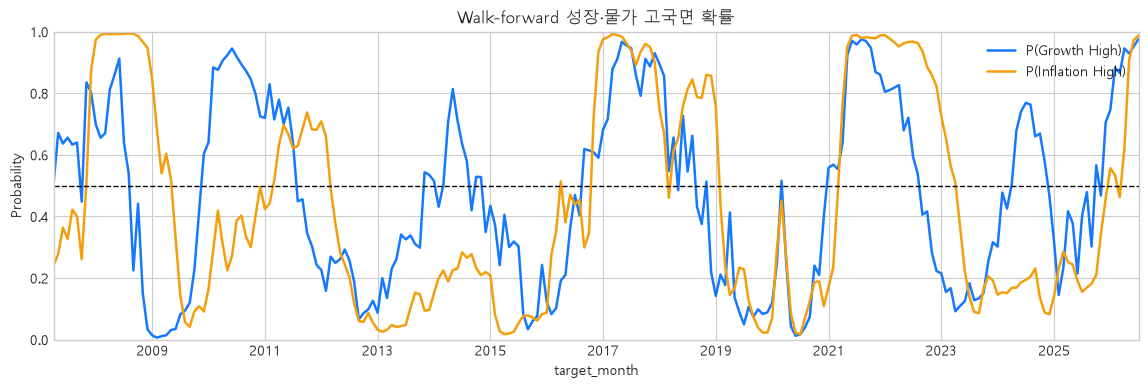

**최신 투자 대상 월:** 2026-07 / **최빈 국면:** Overheating

,Probability
Overheating,96.3%
Stagflation,2.4%
Goldilocks,1.2%
Slowdown,0.0%


In [6]:
regime_eval, regime_metrics = evaluate_regimes(signals, core)

current_state = pd.DataFrame({
    "naive_growth": core[["GDP", "Export", "BSI"]].mean(axis=1) >= 0,
    "naive_inflation": core[["CPI", "PPI", "ImportPrice"]].mean(axis=1) >= 0,
})
regime_compare = regime_eval.join(current_state, how="left")
naive_growth = balanced_accuracy_score(regime_compare["growth_high_realized"], regime_compare["naive_growth"])
naive_inflation = balanced_accuracy_score(regime_compare["inflation_high_realized"], regime_compare["naive_inflation"])
naive_quadrant = (
    (regime_compare["naive_growth"] == regime_compare["growth_high_realized"])
    & (regime_compare["naive_inflation"] == regime_compare["inflation_high_realized"])
).mean()

accuracy_table = pd.DataFrame({
    "SJM-composite ensemble": [
        regime_metrics["growth_balanced_accuracy"],
        regime_metrics["inflation_balanced_accuracy"],
        regime_metrics["quadrant_accuracy"],
    ],
    "Naive persistence": [naive_growth, naive_inflation, naive_quadrant],
}, index=["Growth balanced accuracy", "Inflation balanced accuracy", "4-quadrant accuracy"])
display(accuracy_table.style.format("{:.1%}"))

prob_plot = signals[["p_growth_high", "p_inflation_high"]].copy()
prob_plot.index = prob_plot.index.to_timestamp()
ax = prob_plot.plot(figsize=(14, 4), color=["#1479FF", "#F59E0B"], lw=1.8)
ax.axhline(0.5, color="black", lw=1, ls="--")
ax.set_ylim(0, 1)
ax.set_title("Walk-forward 성장·물가 고국면 확률")
ax.set_ylabel("Probability")
ax.legend(["P(Growth High)", "P(Inflation High)"])
plt.show()

latest_signal = signals.iloc[-1]
latest_probs = pd.Series({r: latest_signal[f"p_{r}"] for r in REGIME_ANCHORS.index}, name="Probability")
display(Markdown(f"**최신 투자 대상 월:** {signals.index[-1]} / **최빈 국면:** {latest_signal['regime']}"))
display(latest_probs.sort_values(ascending=False).to_frame().style.format("{:.1%}"))

## 6. 36개 설정 보정 — `calibrate_configs.py` 통합

보정 기간은 시작 시점부터 **2017-12**까지입니다. 다음 네 항목만 탐색합니다.

- `regime_strength ∈ {0.25, 0.50, 0.75}`
- `target_vol ∈ {0.08, 0.10, 0.12}`
- `invvol_tilt ∈ {0.15, 0.35}`
- `drawdown_guard ∈ {0.40, 0.75}`

목적함수 계수 `1.15, 0.18, 0.25, 0.05, 0.32`와 CDaR 상한 16%는 탐색하지 않고 모든 후보에 고정합니다.

`ValidationScore = Sharpe + 0.35×Calmar − 4×max(|MDD|−15%, 0) − 0.20×AvgTurnover`

In [7]:
def score_metrics(metrics: pd.Series, turnover: float) -> float:
    breach = max(abs(float(metrics["MDD"])) - 0.15, 0.0)
    return float(metrics["Sharpe"] + 0.35 * metrics["Calmar"] - 4.0 * breach - 0.20 * turnover)

calibration_rows = []
calibration_configs = []
candidate_values = list(itertools.product(
    [0.25, 0.50, 0.75],
    [0.08, 0.10, 0.12],
    [0.15, 0.35],
    [0.40, 0.75],
))

for candidate_number, (regime_strength, target_vol, invvol_tilt, drawdown_guard) in enumerate(candidate_values, 1):
    candidate = StrategyConfig(
        name=f"rs{regime_strength}_tv{target_vol}_iv{invvol_tilt}_dg{drawdown_guard}",
        regime_strength=regime_strength,
        target_vol=target_vol,
        invvol_tilt=invvol_tilt,
        drawdown_guard=drawdown_guard,
        return_reward=1.15,
        vol_penalty=0.18,
        cdar_penalty=0.25,
        turnover_penalty=0.05,
        tracking_penalty=0.32,
        max_cdar=0.16,
    )
    calibration_bt = run_backtest(asset_returns, signals, candidate, mode="proposed", end="2017-12")
    metrics = performance_summary(calibration_bt["return"])
    avg_turnover = float(calibration_bt["turnover"].mean())
    calibration_rows.append({
        "name": candidate.name,
        **asdict(candidate),
        **metrics.to_dict(),
        "AvgTurnover": avg_turnover,
        "ValidationScore": score_metrics(metrics, avg_turnover),
    })
    calibration_configs.append(candidate)
    if candidate_number % 6 == 0:
        print(f"보정 진행: {candidate_number:02d}/{len(candidate_values)}")

calibration_grid = (
    pd.DataFrame(calibration_rows)
    .sort_values("ValidationScore", ascending=False)
    .reset_index(drop=True)
)
calibration_grid.to_csv(RESULTS_DIR / "calibration_grid.csv", index=False)

winner_name = calibration_grid.iloc[0]["name"]
winner = next(candidate for candidate in calibration_configs if candidate.name == winner_name)
cfg = StrategyConfig(**{**asdict(winner), "name": "Proposed"})

display(Markdown(f"### 선택된 설정: `{winner_name}`"))
display(calibration_grid[["name", "CAGR", "Sharpe", "MDD", "Calmar", "AvgTurnover", "ValidationScore"]].head(10).style.format({
    "CAGR": "{:.2%}", "Sharpe": "{:.3f}", "MDD": "{:.2%}",
    "Calmar": "{:.3f}", "AvgTurnover": "{:.2%}", "ValidationScore": "{:.3f}",
}))
display(pd.Series(asdict(cfg), name="Locked value").to_frame())

with (RESULTS_DIR / "config.json").open("w", encoding="utf-8") as file:
    json.dump(asdict(cfg), file, ensure_ascii=False, indent=2)

보정 진행: 06/36


보정 진행: 12/36


보정 진행: 18/36


보정 진행: 24/36


보정 진행: 30/36


보정 진행: 36/36


### 선택된 설정: `rs0.75_tv0.08_iv0.35_dg0.75`

,name,CAGR,Sharpe,MDD,Calmar,AvgTurnover,ValidationScore
0,rs0.75_tv0.08_iv0.35_dg0.75,7.38%,1.105,-8.93%,0.826,2.87%,1.389
1,rs0.75_tv0.08_iv0.35_dg0.4,7.37%,1.101,-9.00%,0.819,2.83%,1.382
2,rs0.5_tv0.08_iv0.35_dg0.75,7.20%,1.107,-9.06%,0.795,2.54%,1.380
3,rs0.75_tv0.08_iv0.15_dg0.4,7.53%,1.102,-9.39%,0.801,3.12%,1.376
4,rs0.5_tv0.08_iv0.35_dg0.4,7.19%,1.102,-9.13%,0.788,2.52%,1.373
5,rs0.75_tv0.08_iv0.15_dg0.75,7.37%,1.093,-9.29%,0.793,2.94%,1.365
6,rs0.25_tv0.08_iv0.35_dg0.75,7.02%,1.101,-9.42%,0.745,2.39%,1.357
7,rs0.25_tv0.08_iv0.35_dg0.4,7.01%,1.097,-9.51%,0.737,2.24%,1.351
8,rs0.5_tv0.08_iv0.15_dg0.75,7.15%,1.085,-9.69%,0.738,2.66%,1.338
9,rs0.5_tv0.08_iv0.15_dg0.4,7.12%,1.078,-9.80%,0.727,2.65%,1.327


,Locked value
name,Proposed
target_vol,0.08
half_life,12.0
invvol_tilt,0.35
return_reward,1.15
vol_penalty,0.18
cdar_penalty,0.25
turnover_penalty,0.05
tracking_penalty,0.32
max_cdar,0.16


## 7. 전체기간 walk-forward 백테스트

우승 설정을 잠근 뒤 proposed, soft, hard, equal weight, static defensive, KODEX200 buy-and-hold를 같은 기간과 비용 규칙으로 비교합니다.

In [8]:
mode_labels = {
    "proposed": "Proposed: Regime + Risk control",
    "soft": "Soft regime only",
    "hard": "Original-style hard regime",
    "equal": "Equal weight",
    "static_defensive": "Static defensive",
    "kodex": "KODEX200 B&H",
}

backtests = {mode: run_backtest(asset_returns, signals, cfg, mode=mode) for mode in mode_labels}
summary_by_mode = pd.DataFrame({mode: performance_summary(bt["return"]) for mode, bt in backtests.items()}).T
summary = summary_by_mode.rename(index=mode_labels)

summary_by_mode.to_csv(RESULTS_DIR / "summary.csv")
signals.to_csv(RESULTS_DIR / "regime_signals.csv")
backtests["proposed"].to_csv(RESULTS_DIR / "proposed_backtest.csv")

display(summary.style.format({
    "Months": "{:.0f}", "CAGR": "{:.2%}", "Volatility": "{:.2%}",
    "Sharpe": "{:.3f}", "Sortino": "{:.3f}", "MDD": "{:.2%}",
    "Calmar": "{:.3f}", "FinalMultiple": "{:.2f}x", "PositiveMonths": "{:.1%}",
}).highlight_max(subset=["Sharpe", "Calmar"], color="#d7f5dd"))

,Months,CAGR,Volatility,Sharpe,Sortino,MDD,Calmar,FinalMultiple,PositiveMonths
Proposed: Regime + Risk control,232,8.12%,7.06%,1.144,2.241,-8.93%,0.909,4.53x,64.2%
Soft regime only,232,9.58%,11.34%,0.866,1.475,-19.27%,0.497,5.86x,61.6%
Original-style hard regime,232,18.46%,22.59%,0.867,1.492,-26.67%,0.692,26.44x,61.6%
Equal weight,232,7.51%,12.69%,0.636,0.987,-34.29%,0.219,4.06x,60.3%
Static defensive,232,8.05%,7.73%,1.043,1.875,-11.65%,0.691,4.46x,62.1%
KODEX200 B&H,232,10.80%,23.89%,0.548,0.933,-48.52%,0.223,7.27x,58.6%


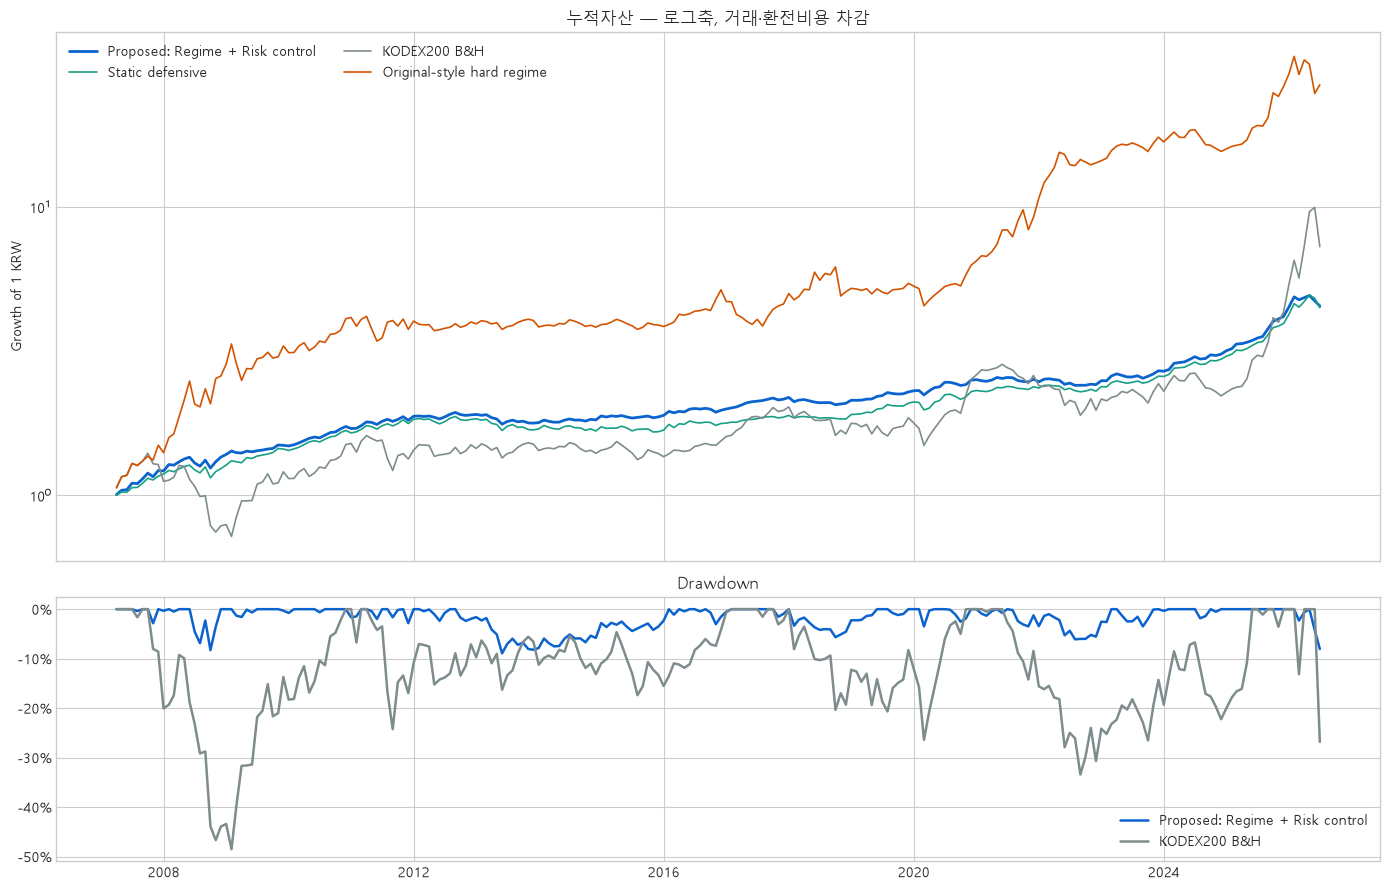

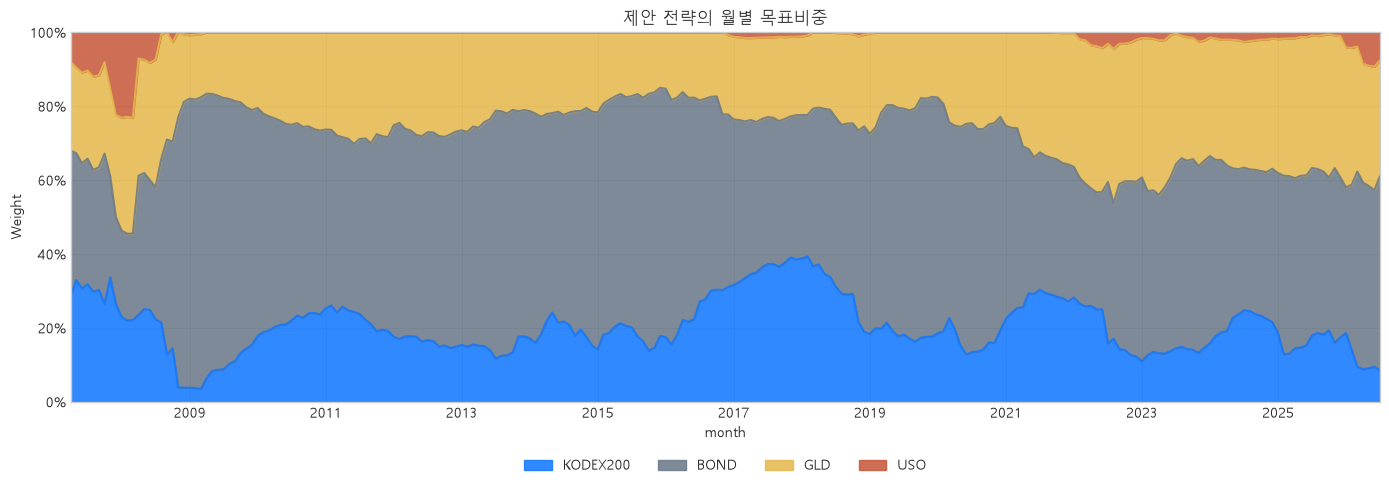

,Average weight,Latest weight
KODEX200,20.4%,8.5%
BOND,51.4%,52.6%
GLD,26.6%,31.3%
USO,1.6%,7.7%


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
colors = {"proposed": "#0B63CE", "static_defensive": "#16A085", "kodex": "#7F8C8D", "hard": "#D35400"}
for key in ["proposed", "static_defensive", "kodex", "hard"]:
    bt = backtests[key]
    idx = bt.index.to_timestamp()
    wealth = (1 + bt["return"]).cumprod()
    axes[0].plot(idx, wealth, label=mode_labels[key], color=colors[key], lw=2 if key == "proposed" else 1.2)
    if key in ["proposed", "kodex"]:
        drawdown = wealth / wealth.cummax() - 1
        axes[1].plot(idx, drawdown, label=mode_labels[key], color=colors[key], lw=1.8)
axes[0].set_yscale("log")
axes[0].set_title("누적자산 — 로그축, 거래·환전비용 차감")
axes[0].set_ylabel("Growth of 1 KRW")
axes[0].legend(ncol=2)
axes[1].set_title("Drawdown")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].legend()
plt.tight_layout()
plt.show()

proposed = backtests["proposed"]
weights = proposed[[f"w_{asset}" for asset in ASSETS]].copy()
weights.columns = ASSETS
weights.index = weights.index.to_timestamp()
ax = weights.plot.area(figsize=(14, 5), color=["#1479FF", "#6C7A89", "#E5B94E", "#C85A3D"], alpha=0.88)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("제안 전략의 월별 목표비중")
ax.set_ylabel("Weight")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.show()

display(pd.concat([
    weights.mean().rename("Average weight"),
    weights.iloc[-1].rename("Latest weight"),
], axis=1).style.format("{:.1%}"))

## 8. 잠금 테스트와 강건성 점검

2018-01 이후는 36개 후보의 우승 설정을 고를 때 점수에 포함하지 않은 잠금 구간입니다. 비용 0배·1배·2배, 주요 위기구간, 12개월 블록 부트스트랩도 함께 확인합니다.

In [10]:
locked_backtests = {
    mode: run_backtest(asset_returns, signals, cfg, mode=mode, start="2018-01")
    for mode in mode_labels
}
locked_summary_by_mode = pd.DataFrame({
    mode: performance_summary(bt["return"]) for mode, bt in locked_backtests.items()
}).T
locked_summary = locked_summary_by_mode.rename(index=mode_labels)
locked_summary_by_mode.to_csv(RESULTS_DIR / "locked_summary.csv")

display(Markdown(f"### 2018-01~{signals.index[-1]} 잠금 구간"))
display(locked_summary.style.format({
    "Months": "{:.0f}", "CAGR": "{:.2%}", "Volatility": "{:.2%}",
    "Sharpe": "{:.3f}", "Sortino": "{:.3f}", "MDD": "{:.2%}",
    "Calmar": "{:.3f}", "FinalMultiple": "{:.2f}x", "PositiveMonths": "{:.1%}",
}))

cost_rows = []
for multiplier in [0.0, 1.0, 2.0]:
    scenario = run_backtest(asset_returns, signals, cfg, mode="proposed", cost_multiplier=multiplier)
    metrics = performance_summary(scenario["return"])
    cost_rows.append({"CostMultiplier": multiplier, **metrics.to_dict(), "AvgTurnover": scenario["turnover"].mean()})
cost_sensitivity = pd.DataFrame(cost_rows).set_index("CostMultiplier")
cost_sensitivity.to_csv(RESULTS_DIR / "cost_sensitivity.csv")

display(Markdown("### 거래·환전비용 민감도"))
display(cost_sensitivity[["CAGR", "Sharpe", "MDD", "Calmar", "AvgTurnover"]].style.format({
    "CAGR": "{:.2%}", "Sharpe": "{:.3f}", "MDD": "{:.2%}",
    "Calmar": "{:.3f}", "AvgTurnover": "{:.2%}",
}))

### 2018-01~2026-07 잠금 구간

,Months,CAGR,Volatility,Sharpe,Sortino,MDD,Calmar,FinalMultiple,PositiveMonths
Proposed: Regime + Risk control,103,9.02%,7.56%,1.183,2.512,-8.05%,1.120,2.10x,64.1%
Soft regime only,103,13.61%,12.54%,1.084,2.035,-14.46%,0.941,2.99x,66.0%
Original-style hard regime,103,22.58%,23.92%,0.978,1.630,-26.67%,0.847,5.74x,62.1%
Equal weight,103,13.48%,14.35%,0.958,1.572,-27.32%,0.493,2.96x,66.0%
Static defensive,103,10.70%,8.25%,1.277,2.595,-9.71%,1.102,2.39x,62.1%
KODEX200 B&H,103,16.43%,28.99%,0.666,1.246,-33.40%,0.492,3.69x,55.3%


### 거래·환전비용 민감도

,CAGR,Sharpe,MDD,Calmar,AvgTurnover
CostMultiplier,,,,,
0.000000,8.22%,1.156,-8.93%,0.921,2.50%
1.000000,8.12%,1.144,-8.93%,0.909,2.51%
2.000000,8.03%,1.132,-8.94%,0.898,2.51%


In [11]:
crises = {
    "Global Financial Crisis": ("2007-10", "2009-03"),
    "COVID shock": ("2020-01", "2020-12"),
    "Inflation shock": ("2022-01", "2022-12"),
}
crisis_rows = []
for episode, (start, end) in crises.items():
    lo, hi = pd.Period(start, "M"), pd.Period(end, "M")
    for key in ["proposed", "static_defensive", "kodex"]:
        episode_returns = backtests[key].loc[lo:hi, "return"]
        if len(episode_returns):
            wealth = (1 + episode_returns).cumprod()
            crisis_rows.append({
                "Episode": episode,
                "Strategy": mode_labels[key],
                "CumulativeReturn": wealth.iloc[-1] - 1,
                "EpisodeMDD": (wealth / wealth.cummax() - 1).min(),
                "Volatility": episode_returns.std() * np.sqrt(12),
            })
crisis_table = pd.DataFrame(crisis_rows)
crisis_table.to_csv(RESULTS_DIR / "crisis_episodes.csv", index=False)

display(Markdown("### 주요 위기 에피소드"))
display(crisis_table.pivot(
    index="Episode", columns="Strategy", values=["CumulativeReturn", "EpisodeMDD"]
).style.format("{:.1%}"))

### 주요 위기 에피소드

In [12]:
def block_bootstrap_metrics(series, n_boot=1000, block=12, seed=42):
    values = np.asarray(series, dtype=float)
    rng = np.random.default_rng(seed)
    starts = np.arange(0, len(values) - block + 1)
    rows = []
    for _ in range(n_boot):
        sample = []
        while len(sample) < len(values):
            start = int(rng.choice(starts))
            sample.extend(values[start:start + block])
        metrics = performance_summary(pd.Series(sample[:len(values)]))
        rows.append([metrics["Sharpe"], metrics["MDD"], metrics["CAGR"]])
    return pd.DataFrame(rows, columns=["Sharpe", "MDD", "CAGR"])

bootstrap = block_bootstrap_metrics(proposed["return"])
bootstrap_ci = bootstrap.quantile([0.025, 0.50, 0.975]).rename(
    index={0.025: "2.5%", 0.50: "Median", 0.975: "97.5%"}
)
bootstrap_ci.to_csv(RESULTS_DIR / "bootstrap_ci.csv")

display(Markdown("### 12개월 블록 부트스트랩"))
display(bootstrap_ci.style.format({"Sharpe": "{:.3f}", "MDD": "{:.2%}", "CAGR": "{:.2%}"}))
display(Markdown("블록 부트스트랩은 월별 의존성을 일부 보존한 표본 불확실성 점검이며 미래 성과 예측구간이 아닙니다."))

### 12개월 블록 부트스트랩

,Sharpe,MDD,CAGR
2.5%,0.665,-15.76%,4.00%
Median,1.156,-9.01%,7.56%
97.5%,1.617,-5.67%,11.90%


블록 부트스트랩은 월별 의존성을 일부 보존한 표본 불확실성 점검이며 미래 성과 예측구간이 아닙니다.

## 9. 자동 검증과 결과 파일

시점, 설정 수, 비중, 비용, 잠금구간 기준을 자동으로 확인합니다. 검증을 통과하면 주요 결과 CSV가 `results/`에 남습니다.

In [13]:
assert len(calibration_grid) == 36
assert winner_name == calibration_grid.iloc[0]["name"]
assert signals.index.is_monotonic_increasing and signals.index.is_unique
assert asset_returns.index.is_monotonic_increasing and asset_returns.index.is_unique
assert (signals["signal_month"] < signals.index).all(), "신호월은 투자월보다 반드시 앞서야 함"
assert np.isfinite(proposed["return"]).all()
assert (weights.sum(axis=1).sub(1).abs() < 1e-8).all()
assert (weights >= -1e-12).all().all()
assert (proposed[["trade_cost", "fx_cost"]] >= 0).all().all()
assert summary_by_mode.loc["proposed", "MDD"] > -0.20
assert locked_summary_by_mode.loc["proposed", "Sharpe"] > 1.0

expected_outputs = [
    "calibration_grid.csv", "config.json", "summary.csv", "locked_summary.csv",
    "regime_signals.csv", "proposed_backtest.csv", "cost_sensitivity.csv",
    "crisis_episodes.csv", "bootstrap_ci.csv",
]
for filename in expected_outputs:
    assert (RESULTS_DIR / filename).exists(), filename

print("모든 시점·설정·비중·비용·잠금구간 검증을 통과했습니다.")
print("선택 설정:", winner_name)
print("전체기간 Sharpe:", round(float(summary_by_mode.loc["proposed", "Sharpe"]), 6))
print("잠금구간 Sharpe:", round(float(locked_summary_by_mode.loc["proposed", "Sharpe"]), 6))
print("결과 폴더:", RESULTS_DIR)

모든 시점·설정·비중·비용·잠금구간 검증을 통과했습니다.
선택 설정: rs0.75_tv0.08_iv0.35_dg0.75
전체기간 Sharpe: 1.143956
잠금구간 Sharpe: 1.182598
결과 폴더: D:\Programming\python_example\RegimeDecisionTest\results


## 10. 해석과 한계

### 현재 설계가 의미하는 것

- 경제 국면은 최종 비중의 방향을 제시하고, 비대칭 EWMA·변동성/CDaR 제약·회전율·tracking·드로다운 가드가 경로위험을 줄입니다.
- `calibration_grid.csv`는 외부 입력이 아니라 이 노트북의 보정 셀이 직접 생성합니다.
- 목적함수의 다섯 계수는 36개 그리드에서 선택된 값이 아니라 고정 휴리스틱입니다.

### 반드시 남는 한계

- 거시자료는 현재 개정치이므로 진정한 point-in-time 빈티지 백테스트가 아닙니다.
- 2009-03 이전 KODEX200은 KOSPI200 프록시입니다.
- 실제 호가 스프레드, 시장충격, 세금, 추적오차는 완전히 반영되지 않습니다.
- 한 번의 보정/잠금 분할은 선택편향을 완전히 제거하지 못합니다.
- 역사적 Sharpe와 MDD는 미래 실거래 성과를 보장하지 않습니다.

### 참고문헌

- Bemporad et al. (2018), [Fitting Jump Models](https://web.stanford.edu/~boyd/papers/fitting_jump_models.html)
- Nystrup, Kolm & Lindström (2021), [Feature Selection in Jump Models](https://doi.org/10.1016/j.eswa.2021.115558)
- Nystrup et al. (2019), [Multi-period Portfolio Selection with Drawdown Control](https://web.stanford.edu/~boyd/papers/pdf/multiperiod_portfolio_drawdown.pdf)
- Moreira & Muir (2017), [Volatility-Managed Portfolios](https://doi.org/10.1111/jofi.12513)
- Chekhlov, Uryasev & Zabarankin (2005), [Drawdown Measure in Portfolio Optimization](https://doi.org/10.1142/S0219024905002767)